<a href="https://colab.research.google.com/github/amrzhd/EEGNet/blob/main/EEGNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Motor Imagery Task Classification


#Installing Packages

In [2]:
# !pip install mne
# !pip install torch-summary

#Libraries Used

In [3]:
import os
import mne
import math
import copy
import gdown
import random
import scipy.io
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

# Torch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchsummary import summary
from torch.autograd import Variable
from torch.utils.data import DataLoader, TensorDataset, random_split

# Scikit-Learn
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

# Building Dataset

##First Session

In [4]:
import numpy as np
import mne
import os

# Set folder paths
raw_data_folder = r"C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets"
cleaned_data_folder = raw_data_folder

# Find training .npz files
files = [f for f in os.listdir(raw_data_folder) if f.endswith('T.npz')]

raw_list = []

# Sampling frequency of BCI Competition IV-2a
sfreq = 250

for file in files:
    file_path = os.path.join(raw_data_folder, file)
    data = np.load(file_path)
    print(f"Processing file: {file} with keys: {data.files}")

    # Transpose so shape is (channels, times)
    signals = data['s'].T  # originally (time, channels)

    # Create MNE Info
    ch_names = [f'EEG{i + 1}' for i in range(signals.shape[0])]
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')

    # Create Raw object
    raw = mne.io.RawArray(signals, info)

    # Filter
    raw.filter(l_freq=4, h_freq=40, method='iir')
    raw.notch_filter(freqs=50)

    # Add annotations if available
    if all(k in data for k in ['etyp', 'epos', 'edur']):
        etyp = data['etyp'].ravel()
        epos = data['epos'].ravel()
        edur = data['edur'].ravel()

        onset = epos / sfreq
        duration = edur / sfreq
        description = [str(int(e)) for e in etyp]

        annotations = mne.Annotations(onset=onset, duration=duration, description=description)
        raw.set_annotations(annotations)

    # Save individual .fif file
    new_file_path = os.path.join(cleaned_data_folder, file.replace('.npz', '.fif'))
    raw.save(new_file_path, overwrite=True)

    raw_list.append(raw)

# Concatenate and save combined .fif file
if raw_list:
    final_raw = mne.concatenate_raws(raw_list)
    final_file_path = os.path.join(cleaned_data_folder, 'First_Session_Subjects.fif')
    final_raw.save(final_file_path, overwrite=True)

    print("✅ All subjects processed and combined.")
else:
    print("⚠️ No raw files were loaded.")


Processing file: A01T.npz with keys: ['s', 'etyp', 'epos', 'edur', 'artifacts']
Creating RawArray with float64 data, n_channels=25, n_times=672528
    Range : 0 ... 672527 =      0.000 ...  2690.108 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 4.00, 40.00 Hz: -6.02, -6.02 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwid

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5656\577166568.py:51: RuntimeWarning: This filename (C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets\A01T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(new_file_path, overwrite=True)


Closing C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets\A01T.fif
[done]
Processing file: A02T.npz with keys: ['s', 'etyp', 'epos', 'edur', 'artifacts']
Creating RawArray with float64 data, n_channels=25, n_times=677169
    Range : 0 ... 677168 =      0.000 ...  2708.672 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 4.00, 40.00 Hz: -6.02, -6.02 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5656\577166568.py:51: RuntimeWarning: This filename (C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets\A02T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(new_file_path, overwrite=True)


Closing C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets\A02T.fif
[done]
Processing file: A03T.npz with keys: ['s', 'etyp', 'epos', 'edur', 'artifacts']
Creating RawArray with float64 data, n_channels=25, n_times=660530
    Range : 0 ... 660529 =      0.000 ...  2642.116 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 4.00, 40.00 Hz: -6.02, -6.02 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (

...

Overwriting existing file.
Writing C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets\A09T.fif


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5656\577166568.py:51: RuntimeWarning: This filename (C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets\A09T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(new_file_path, overwrite=True)


Closing C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets\A09T.fif
[done]
Overwriting existing file.
Writing C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets\First_Session_Subjects.fif


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5656\577166568.py:59: RuntimeWarning: This filename (C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets\First_Session_Subjects.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  final_raw.save(final_file_path, overwrite=True)


Closing C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets\First_Session_Subjects.fif
[done]
✅ All subjects processed and combined.


**List of the events**  
'1023': 1 Rejected trial  
'1072': 2 Eye movements  
'276': 3 Idling EEG (eyes open)  
'277': 4 Idling EEG (eyes closed)  
'32766': 5 Start of a new run  
'768': 6 Start of a trial  
'769': 7 Cue onset **Left** (class 1) : 0  
'770': 8 Cue onset **Right** (class 2) : 1  
'771': 9 Cue onset **Foot** (class 3) : 2  
'772': 10 Cue onset **Tongue** (class 4): 3

In [5]:
event_id = {
    '769': 7,  # left hand
    '770': 8,  # right hand
    '771': 9,  # foot
    '772': 10   # tongue
}

events, _ = mne.events_from_annotations(final_raw, event_id=event_id)
print(events[:10])


Used Annotations descriptions: [np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
[[ 92369      0     10]
 [ 94372      0      9]
 [ 96290      0      8]
 [ 98242      0      7]
 [100250      0      7]
 [102361      0      8]
 [104278      0      9]
 [106328      0     10]
 [108259      0      8]
 [110257      0      9]]


In [6]:
print(set(final_raw.annotations.description))


{np.str_('1072'), np.str_('772'), np.str_('32766'), np.str_('1023'), np.str_('770'), np.str_('EDGE boundary'), np.str_('769'), np.str_('BAD boundary'), np.str_('768'), np.str_('771'), np.str_('276'), np.str_('277')}


**Time choice:**  
[0.s, 4s] Post Cue on set:  [2s, 6s]

In [7]:
epochs = mne.Epochs(final_raw, events, event_id=[7, 8, 9, 10], tmin=0, tmax=4, reject=None, baseline=None, preload=True)
first_session_data = epochs.get_data()
first_session_labels = epochs.events[:, -1]

Not setting metadata
2592 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 2592 events and 1001 original time points ...
0 bad epochs dropped


In [8]:
print("First_session_dataset shape:",first_session_data.shape)

First_session_dataset shape: (2592, 25, 1001)


##Second Session

###Extracting Labels for datas with "E.gdf" prefix

In [9]:
# Replace this with your actual shareable link
shareable_link = 'https://drive.google.com/file/d/11Ke2Xta1kv2xu2Mybuu_X51zJYjQ-VFo/view?usp=drive_link'

# Extract file ID from the shareable link
file_id = shareable_link.split('/d/')[1].split('/view')[0]

# Create the direct download link
download_url = f'https://drive.google.com/uc?id={file_id}&export=download'

# Specify the output file path
output_file = 'true_labels.zip'

# Download the file
gdown.download(download_url, output_file, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=11Ke2Xta1kv2xu2Mybuu_X51zJYjQ-VFo&export=download
To: c:\Users\LENOVO\Documents\Uni\Master Thesis\EEGNet\true_labels.zip
100%|██████████| 7.20k/7.20k [00:00<00:00, 7.20MB/s]


'true_labels.zip'

In [10]:
%%capture
!unzip /content/true_labels.zip -d second_session_labels

###Extracting datas of second session

Processing file: A01E.npz with keys: ['s', 'etyp', 'epos', 'edur', 'artifacts']
Creating RawArray with float64 data, n_channels=25, n_times=687000
    Range : 0 ... 686999 =      0.000 ...  2747.996 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 4.00, 40.00 Hz: -6.02, -6.02 dB

Overwriting existing file.
Writing C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets\A01E.fif


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5656\2255365525.py:52: RuntimeWarning: This filename (C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets\A01E.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(fif_path, overwrite=True)


Closing C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets\A01E.fif
[done]
Processing file: A02E.npz with keys: ['s', 'etyp', 'epos', 'edur', 'artifacts']
Creating RawArray with float64 data, n_channels=25, n_times=662666
    Range : 0 ... 662665 =      0.000 ...  2650.660 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 4.00, 40.00 Hz: -6.02, -6.02 dB

Overwriting existing file.
Writing C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets\A02E.fif


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5656\2255365525.py:52: RuntimeWarning: This filename (C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets\A02E.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(fif_path, overwrite=True)


Closing C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets\A02E.fif
[done]
Processing file: A03E.npz with keys: ['s', 'etyp', 'epos', 'edur', 'artifacts']
Creating RawArray with float64 data, n_channels=25, n_times=648775
    Range : 0 ... 648774 =      0.000 ...  2595.096 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 4.00, 40.00 Hz: -6.02, -6.02 dB

Overwriting existing file.
Writing C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets\A03E.fif


...

Closing C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets\A08E.fif
[done]
Processing file: A09E.npz with keys: ['s', 'etyp', 'epos', 'edur', 'artifacts']
Creating RawArray with float64 data, n_channels=25, n_times=675098
    Range : 0 ... 675097 =      0.000 ...  2700.388 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 4.00, 40.00 Hz: -6.02, -6.02 dB

Overwriting existing file.
Writing C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets\A09E.fif


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5656\2255365525.py:52: RuntimeWarning: This filename (C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets\A09E.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(fif_path, overwrite=True)


Closing C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets\A09E.fif
[done]
Overwriting existing file.
Writing C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets\Second_Session_Subjects.fif


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5656\2255365525.py:58: RuntimeWarning: This filename (C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets\Second_Session_Subjects.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  final_raw.save(final_fif_path, overwrite=True)


Closing C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets\Second_Session_Subjects.fif
[done]


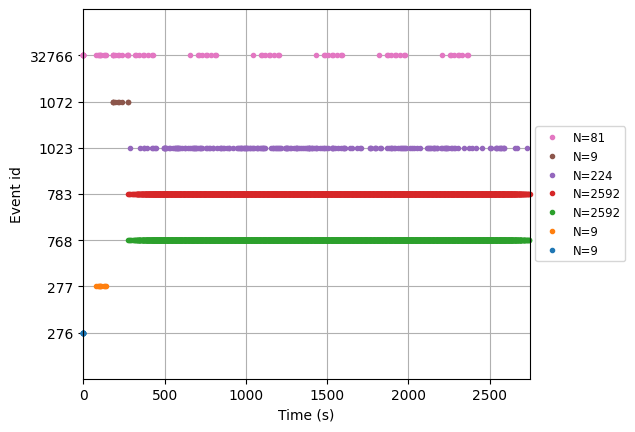

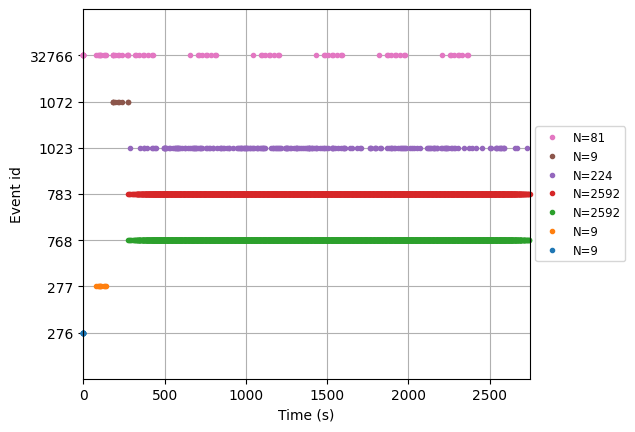

In [11]:
import os
import numpy as np
import mne

raw_data_folder = r"C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets"
cleaned_data_folder = r"C:\Users\LENOVO\Documents\Uni\Master Thesis\FBCSP_BCI_IV2a\datasets"

sfreq = 250  # Sampling frequency

# Event mapping (integer keys to match npz)
event_id = {
    1023: 1,   # Rejected trial
    1072: 2,   # Eye movements
    276: 3,    # Idling EEG (eyes open)
    277: 4,    # Idling EEG (eyes closed)
    32766: 5,  # Start of a new run
    768: 6,    # Start of a trial
    783: 7     # Cue unknown
}

filtered_files = [file for file in os.listdir(raw_data_folder) if file.endswith('E.npz')]

raw_list = []
all_events = []

for file in filtered_files:
    file_path = os.path.join(raw_data_folder, file)
    data = np.load(file_path)
    print(f"Processing file: {file} with keys: {data.files}")

    signals = data['s'].T  # Shape: (channels, samples)

    ch_names = [f'EEG{i + 1}' for i in range(signals.shape[0])]
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
    raw = mne.io.RawArray(signals, info)

    raw.filter(l_freq=4, h_freq=40, method='iir')

    # Create events array from epos and etyp
    etyp = data['etyp']
    epos = data['epos']
    events = np.column_stack((epos, np.zeros_like(etyp), etyp))

    # Optional: filter events to only include types in event_id
    valid_events = np.isin(events[:, 2], list(event_id.keys()))
    events = events[valid_events]

    all_events.append(events)

    # Save raw file
    fif_path = os.path.join(cleaned_data_folder, file.replace('.npz', '.fif'))
    raw.save(fif_path, overwrite=True)
    raw_list.append(raw)

# Concatenate raw data
final_raw = mne.concatenate_raws(raw_list)
final_fif_path = os.path.join(cleaned_data_folder, 'Second_Session_Subjects.fif')
final_raw.save(final_fif_path, overwrite=True)

# Concatenate all events (adjust offsets if needed)
combined_events = np.concatenate(all_events)

# Plot and check events
mne.viz.plot_events(combined_events, sfreq=sfreq)

# Optionally: Create Epochs object
# epochs = mne.Epochs(final_raw, combined_events, event_id=event_id, tmin=-1, tmax=4, preload=True)


**List of the events**  
'1023': 1 Rejected trial  
'1072': 2 Eye movements  
'276': 3 Idling EEG (eyes open)  
'277': 4 Idling EEG (eyes closed)  
'32766': 5 Start of a new run  
'768': 6 Start of a trial  
'783': 7 Cue unknown

In [12]:
file_path = os.path.join(raw_data_folder, filtered_files[0])
data = np.load(file_path)
print(data.files)


['s', 'etyp', 'epos', 'edur', 'artifacts']


In [13]:
print(set(final_raw.annotations.description))
print(set(final_raw.annotations.description))
print(final_raw.annotations)


{np.str_('BAD boundary'), np.str_('EDGE boundary')}
{np.str_('BAD boundary'), np.str_('EDGE boundary')}
<Annotations | 16 segments: BAD boundary (8), EDGE boundary (8)>


In [14]:
# Only keep event codes that are present in the data
present_event_codes = set(combined_events[:, 2])
filtered_event_id = {str(code): code for code in present_event_codes if code in event_id}
print("Filtered event_id for epoching:", filtered_event_id)

# Create epochs using only present events
epochs = mne.Epochs(
    raw=final_raw,
    events=combined_events,
    event_id=filtered_event_id,
    tmin=0,
    tmax=4,
    baseline=None,
    preload=True,
    event_repeated='drop'
)


Filtered event_id for epoching: {'768': np.int32(768), '783': np.int32(783), '1072': np.int32(1072), '276': np.int32(276), '277': np.int32(277), '32766': np.int32(32766), '1023': np.int32(1023)}
Multiple event values for single event times found. Keeping the first occurrence and dropping all others.
Not setting metadata
5228 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 5228 events and 1001 original time points ...
1 bad epochs dropped


In [15]:
valid_codes = list(filtered_event_id.values())

# Filter combined_events to keep only events with valid event codes
filtered_events = combined_events[np.isin(combined_events[:, 2], valid_codes)]

second_session_data = epochs.get_data()
second_session_labels = epochs.events[:, -1]


In [16]:
print("Second Session Dataset shape:",second_session_data.shape)

Second Session Dataset shape: (5227, 25, 1001)


###Structuring Data

In [17]:
# Choosing Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(first_session_data.shape)  # Should be (n_epochs, n_channels, 1001)
print(second_session_data.shape) # Currently (n_epochs, n_channels, 1251)

print("First session epoch duration:", (first_session_data.shape[2] - 1) / sfreq)
print("Second session epoch duration:", (second_session_data.shape[2] - 1) / sfreq)


# Loss Function
criterion = nn.CrossEntropyLoss()

# Normalizing Labels to [0, 1, 2, 3]
y_train = first_session_labels - np.min(first_session_labels)
y_test = second_session_labels - np.min(second_session_labels)

# Normalizing Input features: z-score(mean=0, std=1)
X_first_session = (first_session_data - np.mean(first_session_data)) / np.std(first_session_data)
X_second_session = (second_session_data - np.mean(second_session_data)) / np.std(second_session_data)

X = np.concatenate((X_first_session, X_second_session))
y = np.concatenate((y_train, y_test))

# Spliting  Data: 90% for Train and 10% for Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

# Converting to Tensor
X_train = torch.Tensor(X_train).unsqueeze(1)
X_test = torch.Tensor(X_test).unsqueeze(1).to(device)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test).to(device)

# Creating Tensor Dataset
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# Printing the sizes
print("Size of X_train:", X_train.size())
print("Size of X_test:", X_test.size())
print("Size of y_train:", y_train.size())
print("Size of y_test:", y_test.size())


(2592, 25, 1001)
(5227, 25, 1001)
First session epoch duration: 4.0
Second session epoch duration: 4.0
Size of X_train: torch.Size([7037, 1, 25, 1001])
Size of X_test: torch.Size([782, 1, 25, 1001])
Size of y_train: torch.Size([7037])
Size of y_test: torch.Size([782])


#Training Class

In [18]:
class TrainModel():
    def __init__(self,):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def train_model(self, model, train_dataset, learning_rate=0.001, batch_size=32, epochs=500):
        model = model.to(self.device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        highest_train_accuracy = 0.0

        for epoch in range(epochs):
            model.train()
            running_loss = 0.0
            correct = 0
            total = 0
            for inputs, labels in train_loader:
                inputs = inputs.to(self.device)
                labels = labels.to(self.device)
                

                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            epoch_loss = running_loss / len(train_loader.dataset)
            epoch_accuracy = correct / total
            if epoch_accuracy > highest_train_accuracy:
                highest_train_accuracy = epoch_accuracy
            print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {(epoch_accuracy*100):.2f}%")

        average_loss = running_loss / len(train_loader.dataset)
        print("Average Loss:", average_loss)
        print("Highest Train Accuracy:", highest_train_accuracy)

        # Saving model
        torch.save(model.state_dict(), 'eegnet_model.pth')
        return model


#Evaluating Model

In [19]:
class EvalModel():
    def __init__(self, model):
        self.model = model.to(device)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    def test_model(self, test_dataset):
        self.model.eval()
        correct = 0
        total = 0
        test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(self.device)
                labels = labels.to(self.device)

                inputs = inputs.to(self.device)
                

                outputs = self.model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        accuracy = (correct / total) * 100
        print("/------------------------------/")
        print(f"Test Accuracy: {accuracy:.2f}%")
        print("/------------------------------/")
        return accuracy

    def plot_confusion_matrix(self, test_dataset, classes):
        self.model.eval()
        y_pred = []
        y_true = []
        test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(self.device)
                
                inputs = inputs.to(self.device)
                

                labels = labels.to(self.device)
                outputs = self.model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                y_pred.append(predicted.item())
                y_true.append(labels.item())

        cf_matrix = confusion_matrix(y_true, y_pred)
        cf_matrix = cf_matrix.astype('float') / cf_matrix.sum(axis=1)[:, np.newaxis]

        df_cm = pd.DataFrame(cf_matrix, index=classes, columns=classes)

        plt.figure(figsize=(10, 7))
        sn.heatmap(df_cm, annot=True, cmap='Blues', fmt='.2f')
        plt.xlabel('Predicted labels')
        plt.ylabel('True labels')
        plt.title('Confusion Matrix')
        plt.savefig('confusion_matrix_model.png')
        plt.show()


#EEGNet Model

In [20]:
import torch
import torch.nn as nn

class EEGNetModel(nn.Module):
    def __init__(self, chans=22, classes=4, time_points=1001, temp_kernel=32,
                 f1=16, f2=32, d=2, pk1=8, pk2=16, dropout_rate=0.5,
                 max_norm1=1.0, max_norm2=0.25):
        super(EEGNetModel, self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, f1, (1, temp_kernel), padding='same', bias=False),
            nn.BatchNorm2d(f1),
            nn.Conv2d(f1, f2, (chans, 1), groups=f1, bias=False),
            nn.BatchNorm2d(f2),
            nn.ELU(),
            nn.AvgPool2d((1, pk1)),
            nn.Dropout(dropout_rate)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(f2, f2, (1, 16), groups=f2, padding='same', bias=False),
            nn.BatchNorm2d(f2),
            nn.ELU(),
            nn.AvgPool2d((1, pk2)),
            nn.Dropout(dropout_rate)
        )

        self.flatten = nn.Flatten()

        # Dynamically compute correct fc input size
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, chans, time_points)
            dummy_output = self.block2(self.block1(dummy_input))
            linear_size = dummy_output.view(1, -1).shape[1]
            print(f"[DEBUG] Computed linear_size: {linear_size}")  # should match your data

        self.fc = nn.Linear(linear_size, classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x


##Model Summery

In [21]:
input_size = (1, 22, 1001)
eegnet_model = EEGNetModel(chans=22).to(device)
summary(eegnet_model, input_size)

c:\Users\LENOVO\Documents\Uni\Master Thesis\eeg_bci_env\lib\site-packages\torch\nn\modules\conv.py:549: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1037.)
  return F.conv2d(


[DEBUG] Computed linear_size: 224


KeyboardInterrupt: 

##Training Model

In [22]:
# Filter train and test datasets to only include valid class labels (0, 1, 2, 3)
valid_class_indices_train = (y_train >= 0) & (y_train < 4)
valid_class_indices_test = (y_test >= 0) & (y_test < 4)

X_train_filtered = X_train[valid_class_indices_train]
y_train_filtered = y_train[valid_class_indices_train]
X_test_filtered = X_test[valid_class_indices_test]
y_test_filtered = y_test[valid_class_indices_test]

train_dataset_filtered = TensorDataset(X_train_filtered, y_train_filtered)
test_dataset_filtered = TensorDataset(X_test_filtered, y_test_filtered)
actual_time_points = X_train_filtered.shape[-1]
eegnet_model = EEGNetModel(chans=25, classes = 4, time_points=actual_time_points).to(device)

# Training Hyperparameters
EPOCHS = 500
BATCH_SIZE = 32
LEARNING_RATE = 0.001
trainer = TrainModel()
trained_eegnet_model = trainer.train_model(
    eegnet_model,
    train_dataset_filtered,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS
)
torch.save(trained_eegnet_model.state_dict(), 'eegnet_model.pth')


[DEBUG] Computed linear_size: 224


KeyboardInterrupt: 

##Evaluating Model

In [ ]:
classes_list = ['Left', 'Right', 'Foot', 'Tongue']
eval_model = EvalModel(trained_eegnet_model)
test_accuracy = eval_model.test_model(test_dataset_filtered)
eval_model.plot_confusion_matrix(test_dataset_filtered, classes_list)


In [23]:
if torch.cuda.is_available():
    print("CUDA device count:", torch.cuda.device_count())
    print("Current device index:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name(torch.cuda.current_device()))
else:
    print("CUDA is not available.")

CUDA device count: 1
Current device index: 0
Device name: NVIDIA GeForce MX350
